 1. Загрузите выборку из файла gbm-data.csv с помощью pandas и пре
образуйте ее в массив numpy (параметр values у датафрейма). В первой колонке файла с данными записано, была или нет реакция. Все остальные колонки (d1- d1776) содержат различные характеристики молекулы, такие как размер, форма и т.д. Разбейте выборку на обучающую и тестовую, используя функцию train_test_split с параметрами test_size = 0.8 и random_state = 241.

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
df = pd.read_csv("gbm-data.csv")

X = df.drop('Activity', axis=1).values
y = df['Activity'].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.8, random_state=241
)


 2. ОбучитеGradientBoostingClassifier с параметрами n_estimators=250,
 verbose=True, random_state=241 и для каждого значения learning_rate
 из списка [1, 0.5, 0.3, 0.2, 0.1] проделайте следующее: Используйте метод staged_decision_function для предсказания качества на обучающей и тестовой выборке на каждой итерации.
 Преобразуйте полученное предсказание по формуле 1 1+e y_pred, где y_pred предсказанное значение. Вычислите и постройте график значений log-loss на обучающей и тестовой выборках, а также найдите минимальное значение метрики и номер итерации, на которой оно достигается.


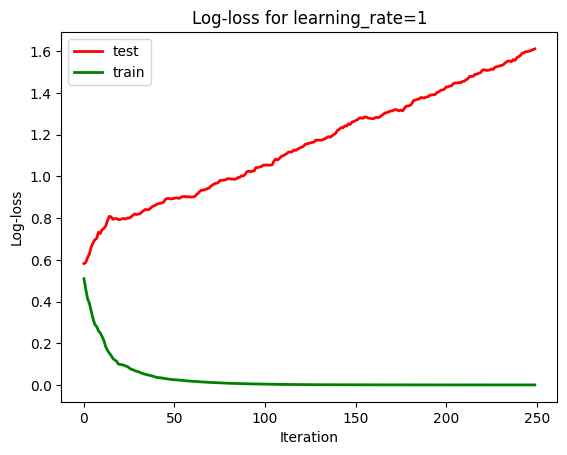

learning_rate=1 -> Min Log-loss: 0.5823 at iteration 0


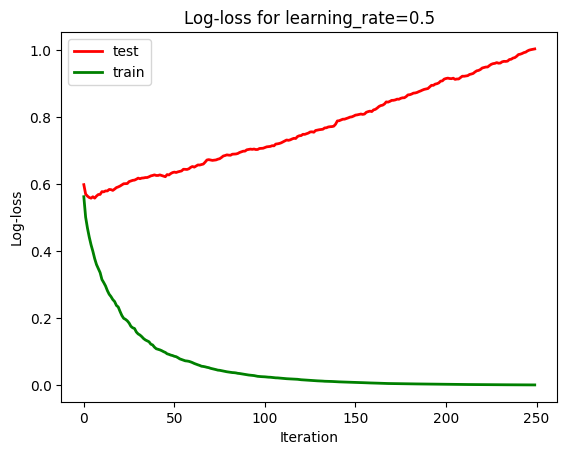

learning_rate=0.5 -> Min Log-loss: 0.5585 at iteration 4


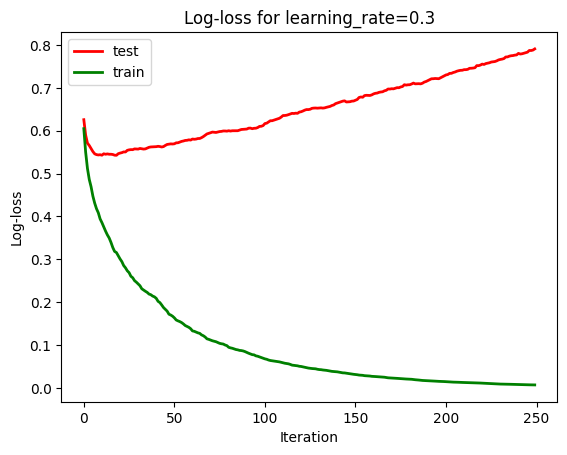

learning_rate=0.3 -> Min Log-loss: 0.5426 at iteration 18


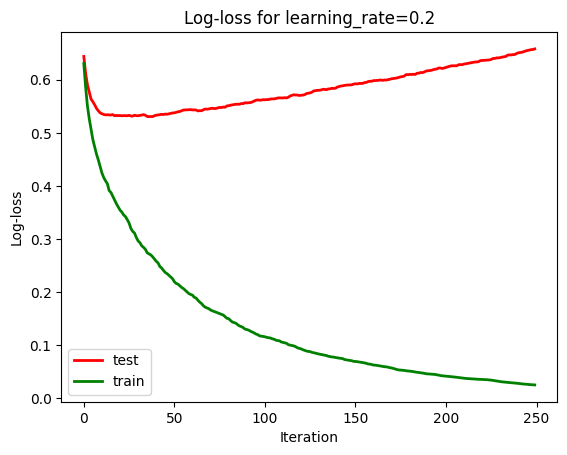

learning_rate=0.2 -> Min Log-loss: 0.5305 at iteration 36


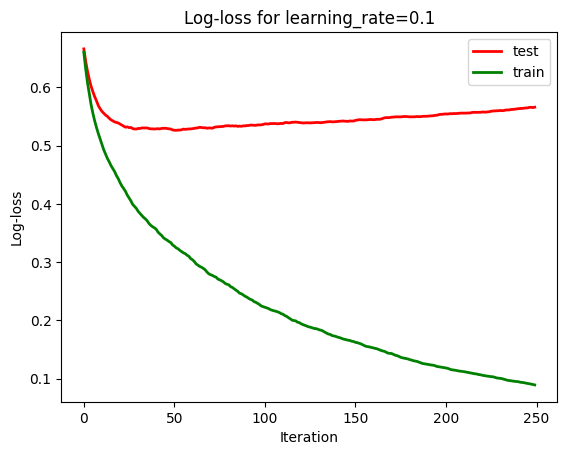

learning_rate=0.1 -> Min Log-loss: 0.5261 at iteration 51


In [ ]:
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import log_loss
import numpy as np
import matplotlib.pyplot as plt

learning_rates = [1, 0.5, 0.3, 0.2, 0.1]

for lr in learning_rates:
    clf = GradientBoostingClassifier(
        n_estimators=250, learning_rate=lr, verbose=False, random_state=241
    )
    clf.fit(X_train, y_train)

    train_loss = []
    test_loss = []

    for y_pred_train, y_pred_test in zip(
        clf.staged_decision_function(X_train),
        clf.staged_decision_function(X_test)
    ):
        prob_train = 1 / (1 + np.exp(-y_pred_train))
        prob_test = 1 / (1 + np.exp(-y_pred_test))

        train_loss.append(log_loss(y_train, prob_train))
        test_loss.append(log_loss(y_test, prob_test))

    plt.figure()
    plt.plot(test_loss, 'r', linewidth=2)
    plt.plot(train_loss, 'g', linewidth=2)
    plt.legend(['test', 'train'])
    plt.title(f'Log-loss for learning_rate={lr}')
    plt.xlabel('Iteration')
    plt.ylabel('Log-loss')
    plt.show()

    min_loss = min(test_loss)
    best_iter = test_loss.index(min_loss)
    print(f"learning_rate={lr} -> Min Log-loss: {min_loss:.4f} at iteration {best_iter}")


3. Как можно охарактеризовать график качества на тестовой выборке, начиная с некоторой итерации: переобучение (overfitting) или недообучение (underfitting)? В ответе укажите одно из слов overfitting либо underfitting.

По графикам видно, что после меньше чем 50 итераций логлосс на тесте скор начинает ухудшаться, в то время как на трейне он продолжает уменьшаться. Это признак переобучения

 4. Приведите минимальное значение log-loss на тестовой выборке и номер итерации, на котором оно достигается, при learning_rate = 0.2.

learning_rate=0.2 -> Min Log-loss: 0.5305 at iteration 36

 5. На этих же данных обучите RandomForestClassifier с количеством деревьев, равным количеству итераций, на котором достигается наилучшее качество у градиентного бустинга из предыдущего пункта, random_state=241 и остальными параметрами по умолчанию. Какое значение log-loss на тесте получается у этого случайного леса? (Не забывайте, что предсказания нужно получать с помощью функции predict_proba. В данном случае брать сигмоиду от оценки вероятности класса не нужно)

In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=36, random_state=241)
rf.fit(X_train, y_train)

probs = rf.predict_proba(X_test)
loss = log_loss(y_test, probs)
print(f"Random Forest log-loss: {loss:.4f}")


Random Forest log-loss: 0.5416
